# Extracción de $K_F$ y $A_F$ del Level 1 a partir de PDKs comerciales

El Level 1 de SPICE no trae parámetros de ruido flicker calibrados: solo tiene $K_F$ y $A_F$. Para que el modelo didáctico de Razavi (`razavi_cmos.lib`) tenga un ruido con **magnitudes similares a las de un proceso real** (aunque no idénticas, porque el Level 1 es un modelo educativo), este notebook mide el ruido de dos PDKs de código abierto en ngspice y traduce esa medición a los parámetros $K_F$ y $A_F$ del Level 1:

| PDK | Dispositivos | Alimentación | Modelo |
|---|---|---|---|
| **sky130** | `sky130_fd_pr__nfet_01v8`, `pfet_01v8` | 1.8 V | BSIM4 v4.5 (`level=54`) |
| **gf180mcuD** | `nfet_03v3`, `pfet_03v3` | 3.3 V | BSIM4 v4.5 (`level=54`) |

**Idea del método.**

1. Se simula un transistor en fuente común con una carga ideal (un inductor enorme: corto en DC, abierto en AC) para que el único ruido sea el del transistor.
2. `.noise` entrega el ruido referido a la entrada $S_{V_{in}}(f)$; la densidad de ruido de la corriente de drenador es $S_{I_D}=S_{V_{in}}\,g_m^2$.
3. A frecuencias bajas ($1$ Hz a $1$ kHz) domina el flicker, así que $S_{I_D}\approx S_{I_D,fl}$.
4. Se despeja $K_F$ de la expresión del Level 1 y se estudia cómo cambia con la corriente (da $A_F$), con la frecuencia y con la geometría.

**Convención del código.** Se evitan las funciones propias: el código se escribe paso a paso y con comentarios. Solo se recorre con ciclos `for` una lista de casos de simulación (un caso = un dispositivo, una geometría y una corriente).

## Ecuaciones

### Ruido flicker del Level 1 en ngspice

$$S_{I_D,fl}(f)=\frac{K_F\,I_D^{A_F}}{f\;W L\;C_{ox}^2}\qquad[\text{A}^2/\text{Hz}],\qquad C_{ox}=\frac{\epsilon_{ox}}{t_{ox}}.$$

El exponente de la frecuencia está fijo en 1 (no existe un parámetro $E_F$) y $C_{ox}$ sale de `tox`.

### Del PDK al Level 1

Con la densidad medida $S_{I_D}(f_0)$ en el punto de operación $(I_D,\,W,\,L)$ y $A_F=1$:

$$K_F^{eq}(f_0)=\frac{S_{I_D}(f_0)\;f_0\;W L\;C_{ox}^2}{I_D}.$$

**Se usa siempre la $C_{ox}$ de Razavi** ($t_{ox}=4$ nm), no la del PDK, para que el valor obtenido se pueda copiar directo a `razavi_cmos.lib`.

### Dependencia con la corriente y con la frecuencia

Si $S_{I_D,fl}(1\,\text{Hz})\propto I_D^{A_F}$, el exponente efectivo es la pendiente en escala log-log:

$$A_F^{eff}=\frac{d\log S_{I_D}(1\,\text{Hz})}{d\log I_D}.$$

De igual forma, el exponente de frecuencia efectivo es $E_F^{eff}=-\,d\log S_{I_D}/d\log f$ entre $1$ Hz y $1$ kHz. El Level 1 solo puede imitar $E_F=1$, así que $K_F^{eq}$ depende de la frecuencia $f_0$ en la que se calibre si el PDK tiene $E_F\neq1$.

### Por qué BSIM4 no tiene `kf` y `af` aquí

Ambos PDKs usan `fnoimod=1` (modelo unificado de flicker), cuyos parámetros son `noia`, `noib`, `noic`, `em` y `ef`; `kf` y `af` se ignoran. Por eso no se pueden leer directamente: hay que **medir**.

In [1]:
# Paso 1: importar las librerias
import logging
import os
import re
import shutil
import subprocess
import tempfile
import time
from pathlib import Path

import numpy as np                  # calculos numericos
import matplotlib.pyplot as plt     # graficas

from prettytable import PrettyTable          # tablas de resultados

# Paso 2: estilo de las graficas (Arial si esta instalada; si no, la siguiente fuente de la lista)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

C_SKY = "#2a78d6"      # sky130
C_GF = "#eb6834"       # gf180mcuD
C_L1 = "#52514e"       # Level 1 (Razavi)

## Constantes y rutas

La $C_{ox}$ de Razavi se calcula con $t_{ox}=40$ Å. Las simulaciones se ejecutan en una carpeta temporal, para no ensuciar el repositorio; ahí se enlazan los archivos del PDK de gf180 (sus `.include` y `.lib` son relativos al directorio de trabajo).

In [2]:
# Paso 1: constantes fisicas y temperatura de la simulacion (ngspice usa temp = 27 C)
k = 1.380649e-23         # Constante de Boltzmann (J/K)
T = 27.0 + 273.15        # Temperatura (K)
eps0 = 8.854214871e-12   # Permitividad del vacio (F/m)

# Paso 2: Cox del Level 1 de Razavi (tox = 4 nm). Con ella se calcula KF para razavi_cmos.lib
tox_razavi = 40e-10
Cox_razavi = 3.9 * eps0 / tox_razavi
print(f"Cox (Razavi) = {Cox_razavi * 1e3:.2f} mF/m^2")

# Paso 3: rutas. Este notebook vive en ngspice/Razavi; los PDKs estan en ngspice/
NG_DIR = Path.cwd().resolve().parent
SKY_LIB = NG_DIR / "sky130A_min/libs.tech/combined/sections/sky130_tt.lib.spice"
GF_DIR = NG_DIR / "gf180mcuD"
assert SKY_LIB.exists() and GF_DIR.exists(), "No se encuentran los PDKs; ejecuta el notebook desde ngspice/Razavi"
assert shutil.which("ngspice"), "ngspice no esta instalado"

# Paso 4: carpeta de trabajo temporal con enlaces a los archivos del PDK de gf180
WORK = Path(tempfile.mkdtemp(prefix="kf_af_"))
for nombre in ("design.ngspice", "sm141064.ngspice", "gf180mcuD_ltspice.lib"):
    os.symlink(GF_DIR / nombre, WORK / nombre)
print("carpeta de trabajo:", WORK)

Cox (Razavi) = 8.63 mF/m^2
carpeta de trabajo: /tmp/kf_af_b140rn93


## Configuración de cada PDK

Los dos PDKs se simulan igual, con tres diferencias que se resumen en el diccionario `PDKS`:

| | sky130 | gf180mcuD |
|---|---|---|
| Unidades de $W$, $L$ | micras (`w=1 l=0.18`) | metros con sufijo (`w=1u l=0.28u`) |
| Longitud mínima usada | 0.18 µm | 0.28 µm |
| Ruta de la corriente del dispositivo | `@m.xm1.m<modelo>[id]` | `@m.xm1.x1.m0[id]` (subcircuito envolvente) |
| $V_{DD}$, $V_{DS}$ | 1.8 V, 0.9 V | 3.3 V, 1.65 V |

El punto de comparación es **$I_D\approx76\,\mu$A con $W=1\,\mu$m**, que es la corriente del transistor de Razavi con $V_{GS}=0.9$ V, $W=1\,\mu$m y $L=0.18\,\mu$m; $V_{DS}$ es la mitad de la alimentación, igual que en los circuitos de Razavi.

El circuito de prueba (para el NMOS; en el PMOS la fuente va a $V_{DD}$ y la carga ideal se conecta a $V_{DD}-V_{DS}$):

```
Vdr ── Lbig(1 GH) ── d ─┐
                        M1 ── s = 0 V
            Vg(dc,ac=1) ── g
```

In [3]:
# Paso 1: configuracion de cada PDK
PDKS = {
    "sky130": dict(
        cabecera=f".lib {SKY_LIB} tt\n",                        # esquina tipica
        sub={"n": "sky130_fd_pr__nfet_01v8", "p": "sky130_fd_pr__pfet_01v8"},
        inst={"n": "@m.xm1.msky130_fd_pr__nfet_01v8", "p": "@m.xm1.msky130_fd_pr__pfet_01v8"},
        geom=lambda W, L: f"w={W} l={L}",                       # micras
        VDD=1.8, L0=0.18,
    ),
    "gf180": dict(
        cabecera=".include design.ngspice\n.lib sm141064.ngspice typical\n.include gf180mcuD_ltspice.lib\n",
        sub={"n": "xnfet_03v3", "p": "xpfet_03v3"},
        inst={"n": "@m.xm1.x1.m0", "p": "@m.xm1.x1.m0"},
        geom=lambda W, L: f"w={W}u l={L}u",                     # metros con sufijo u
        VDD=3.3, L0=0.28,
    ),
}
for p in PDKS.values():
    p["VDS"] = p["VDD"] / 2          # mismo criterio que en los circuitos de Razavi: VDS = VDD/2

# Paso 2: corrientes y geometrias a estudiar
W0 = 1.0                                                   # ancho de referencia (um)
ID_REF = 76e-6                                             # corriente de referencia (A)
corrientes = [10e-6, 20e-6, 40e-6, 76e-6, 120e-6, 200e-6]  # barrido de corriente (geometria de referencia)
geometrias_extra = [(1.0, 0.5), (4.0, 0.5), (1.0, 1.0)]    # (W, L) adicionales; Id = 76 uA * W/1um

## Lista de casos

Cada caso es una tupla `(pdk, tipo, W, L, Id, fnoicor)`:

* barrido de corriente en la geometría de referencia (para $A_F$),
* otras geometrías con la misma densidad de corriente $I_D/W$ (para ver cómo escala $K_F$ con el área),
* la esquina pesimista de ruido de gf180mcuD (`fnoicor=1`).

El parámetro `fnoicor` del PDK gf180 selecciona entre el ruido típico (0) y el de peor caso (1).

In [4]:
casos = []
for pdk, cfg in PDKS.items():
    L0 = cfg["L0"]
    for tipo in ("n", "p"):
        # barrido de corriente en W = 1 um, L minima
        for Id in corrientes:
            casos.append((pdk, tipo, W0, L0, Id, 0))
        # otras geometrias con Id/W = 76 uA/um (la geometria minima ya esta en el barrido)
        for (W, L) in [(4.0, L0)] + geometrias_extra:
            casos.append((pdk, tipo, W, L, ID_REF * W / W0, 0))
# esquina pesimista de gf180 en el punto de referencia
for tipo in ("n", "p"):
    casos.append(("gf180", tipo, W0, PDKS["gf180"]["L0"], ID_REF, 1))
print(len(casos), "casos de simulacion")

42 casos de simulacion


## Simulaciones

Para cada caso:

1. **Barrido DC** (una vez por dispositivo y geometría) del voltaje de compuerta, para encontrar el $|V_{GS}|$ que da la corriente objetivo (se interpola $V_g$ contra $I_D$).
2. **`.op` + `.noise`** en ese punto: se guardan $I_D$ y $g_m$ del `.op`, y `inoise_spectrum` (V/√Hz, referido a la entrada) de $1$ Hz a $100$ MHz, 20 puntos por década.
3. Se convierte a corriente: $S_{I_D}=S_{V_{in}}\,g_m^2$.

Las corridas tardan algunos minutos en total (BSIM4 es mucho más pesado que el Level 1).

In [5]:
resultados = []        # un diccionario por caso con Id, gm, f, Sid, ...
cache_vg = {}          # (pdk, tipo, W, L, fnoicor) -> (Vg del barrido, Id del barrido)
t0 = time.time()

for (pdk, tipo, W, L, Id_obj, fnoicor) in casos:
    cfg = PDKS[pdk]
    sub, inst, VDD, VDS = cfg["sub"][tipo], cfg["inst"][tipo], cfg["VDD"], cfg["VDS"]
    extra = f".param fnoicor={fnoicor}\n" if fnoicor else ""

    # Paso 1: netlist del transistor con carga ideal. @VG@ se reemplaza por el voltaje DC de compuerta
    if tipo == "n":
        circuito = (f"Vdr dr 0 {VDS}\nLbig dr d 1e9\nVg g 0 dc @VG@ ac 1\n"
                    f"XM1 d g 0 0 {sub} {cfg['geom'](W, L)}\n")
        barrido = f"dc Vg 0.3 {VDD} 0.01"
    else:
        circuito = (f"Vdd vdd 0 {VDD}\nVdr dr 0 {VDD - VDS}\nLbig dr d 1e9\nVg g 0 dc @VG@ ac 1\n"
                    f"XM1 d g vdd vdd {sub} {cfg['geom'](W, L)}\n")
        barrido = f"dc Vg 0 {VDD - 0.3} 0.01"
    base = "* extraccion de ruido\n" + cfg["cabecera"] + extra + ".temp 27\n"

    # Paso 2: barrido DC (una vez por dispositivo/geometria) para mapear Id -> |Vgs|
    clave = (pdk, tipo, W, L, fnoicor)
    if clave not in cache_vg:
        net = (base + circuito.replace("@VG@", "0.9") +
               f".control\n set noaskquit\n save {inst}[id]\n {barrido}\n wrdata dc.txt {inst}[id]\n quit\n.endc\n.end\n")
        (WORK / "dc.cir").write_text(net)
        subprocess.run(["ngspice", "-b", "dc.cir"], cwd=WORK, capture_output=True, text=True)
        d = np.loadtxt(WORK / "dc.txt")
        vg_barrido, id_barrido = d[:, 0], np.abs(d[:, 1])
        if tipo == "p":
            vg_barrido = VDD - vg_barrido          # en el PMOS |Vgs| = VDD - Vg
        orden = np.argsort(id_barrido)
        cache_vg[clave] = (vg_barrido[orden], id_barrido[orden])
    vg_ord, id_ord = cache_vg[clave]
    # Si el barrido no alcanza la corriente pedida (p. ej. PMOS de sky130 con |Vgs| <= VDD), se omite el caso
    if Id_obj > id_ord.max() * 0.999:
        print(f"omitido: {pdk} {tipo.upper()}MOS W={W} L={L} Id={Id_obj*1e6:.0f} uA no se alcanza con |Vgs| <= {VDD} V")
        continue
    vgs = float(np.interp(Id_obj, id_ord, vg_ord))        # |Vgs| que da la corriente objetivo

    # Paso 3: .op y .noise en ese punto (Vg dc = |Vgs| en NMOS, VDD - |Vgs| en PMOS)
    vg_dc = vgs if tipo == "n" else VDD - vgs
    net = (base + circuito.replace("@VG@", f"{vg_dc:.6f}") +
           f".control\n set noaskquit\n op\n print {inst}[id] {inst}[gm]\n"
           f" noise v(d) Vg dec 20 1 1e8\n setplot noise1\n wrdata noise.txt inoise_spectrum\n quit\n.endc\n.end\n")
    (WORK / "noise.cir").write_text(net)
    salida = subprocess.run(["ngspice", "-b", "noise.cir"], cwd=WORK, capture_output=True, text=True)
    op = {m.group(1): float(m.group(2)) for m in re.finditer(r"\[(\w+)\]\s*=\s*([-+0-9.eE]+)", salida.stdout)}
    d = np.loadtxt(WORK / "noise.txt")
    f = d[:, 0]
    S_vin = d[:, 1]**2                                     # V^2/Hz referido a la entrada
    resultados.append(dict(pdk=pdk, tipo=tipo, W=W, L=L, fnoicor=fnoicor, vgs=vgs,
                           Id=abs(op["id"]), gm=op["gm"], f=f, S_vin=S_vin, Sid=S_vin * op["gm"]**2))

print(f"{len(resultados)} casos simulados en {time.time() - t0:.0f} s (los demas se omitieron)")

omitido: sky130 PMOS W=1.0 L=0.18 Id=200 uA no se alcanza con |Vgs| <= 1.8 V
omitido: sky130 PMOS W=1.0 L=0.5 Id=76 uA no se alcanza con |Vgs| <= 1.8 V


omitido: sky130 PMOS W=4.0 L=0.5 Id=304 uA no se alcanza con |Vgs| <= 1.8 V
omitido: sky130 PMOS W=1.0 L=1.0 Id=76 uA no se alcanza con |Vgs| <= 1.8 V


omitido: gf180 PMOS W=1.0 L=1.0 Id=76 uA no se alcanza con |Vgs| <= 3.3 V
37 casos simulados en 3 s (los demas se omitieron)


## Resultados: barrido de corriente en la geometría de referencia

Para cada dispositivo se tabula, en cada corriente:

* $g_m$ y $S_{V_{in}}$ a 1 Hz,
* $K_F^{eq}$ calculado a $f_0=1$ Hz y a $f_0=1$ kHz (si son iguales, el ruido es $1/f$ exacto),
* el exponente efectivo de frecuencia $E_F^{eff}$ entre 1 Hz y 1 kHz.

Después se ajusta la pendiente de $S_{I_D}(1\,\text{Hz})$ contra $I_D$ para obtener $A_F^{eff}$.

In [6]:
resumen = {}      # (pdk, tipo) -> dict con af_eff, kf a 1 Hz y 1 kHz en el punto de referencia, ef_eff
for pdk, cfg in PDKS.items():
    for tipo in ("n", "p"):
        # Paso 1: casos del barrido de corriente (geometria de referencia, fnoicor = 0)
        sel = [r for r in resultados if r["pdk"] == pdk and r["tipo"] == tipo and r["fnoicor"] == 0
               and r["W"] == W0 and r["L"] == cfg["L0"]]
        sel.sort(key=lambda r: r["Id"])

        tabla = PrettyTable(["Id [uA]", "|Vgs| [V]", "gm [uS]", "Sin(1Hz) [uV/rtHz]", "Sid(1Hz) [A^2/Hz]",
                             "KF(1Hz)", "KF(1kHz)", "ef_eff"])
        Id_arr, S1_arr = [], []
        for r in sel:
            f, Sid, Id = r["f"], r["Sid"], r["Id"]
            # Paso 2: Sid a 1 Hz y a 1 kHz (interpolando en escala log-log)
            S1 = np.interp(0.0, np.log10(f), np.log10(Sid)); S1 = 10**S1
            S1k = 10**np.interp(3.0, np.log10(f), np.log10(Sid))
            # Paso 3: KF equivalente (af = 1) a 1 Hz y a 1 kHz
            kf1 = S1 * 1.0 * (r["W"] * 1e-6) * (r["L"] * 1e-6) * Cox_razavi**2 / Id
            kf1k = S1k * 1e3 * (r["W"] * 1e-6) * (r["L"] * 1e-6) * Cox_razavi**2 / Id
            # Paso 4: exponente de frecuencia efectivo entre 1 Hz y 1 kHz
            m = (f >= 1) & (f <= 1e3)
            ef = -np.polyfit(np.log10(f[m]), np.log10(Sid[m]), 1)[0]
            tabla.add_row([f"{Id*1e6:.1f}", f"{r['vgs']:.3f}", f"{r['gm']*1e6:.1f}", f"{np.sqrt(S1)/r['gm']*1e6:.2f}",
                           f"{S1:.3e}", f"{kf1:.3e}", f"{kf1k:.3e}", f"{ef:.3f}"])
            Id_arr.append(Id); S1_arr.append(S1)
            if abs(Id - ID_REF) < 1e-9 * 1e3:
                ref = dict(kf1=kf1, kf1k=kf1k, ef=ef, S1=S1, Id=Id, gm=r["gm"])
        # Paso 5: af efectivo = pendiente log-log de Sid(1 Hz) contra Id
        af_eff = np.polyfit(np.log10(Id_arr), np.log10(S1_arr), 1)[0]
        ref["af_eff"] = af_eff
        resumen[(pdk, tipo)] = ref
        print(f"\n{pdk}  {'NMOS' if tipo == 'n' else 'PMOS'}   W = {W0:.0f} um, L = {cfg['L0']} um, "
              f"VDS = {cfg['VDS']} V     ->   af_eff = {af_eff:.3f}")
        print(tabla)


sky130  NMOS   W = 1 um, L = 0.18 um, VDS = 0.9 V     ->   af_eff = 0.706
+---------+-----------+---------+--------------------+-------------------+-----------+-----------+--------+
| Id [uA] | |Vgs| [V] | gm [uS] | Sin(1Hz) [uV/rtHz] | Sid(1Hz) [A^2/Hz] |  KF(1Hz)  |  KF(1kHz) | ef_eff |
+---------+-----------+---------+--------------------+-------------------+-----------+-----------+--------+
|   10.0  |   0.796   |  125.4  |       34.73        |     1.897e-17     | 2.547e-29 | 7.694e-29 | 0.840  |
|   20.0  |   0.859   |  195.5  |       33.95        |     4.408e-17     | 2.957e-29 | 8.930e-29 | 0.840  |
|   40.0  |   0.945   |  275.8  |       32.42        |     7.993e-17     | 2.681e-29 | 8.097e-29 | 0.840  |
|   76.0  |   1.063   |  348.7  |       30.77        |     1.152e-16     | 2.033e-29 | 6.139e-29 | 0.840  |
|  120.0  |   1.185   |  395.3  |       29.80        |     1.388e-16     | 1.551e-29 | 4.685e-29 | 0.840  |
|  200.0  |   1.384   |  436.6  |       29.23        |     1.

### Cómo leer la tabla

* **$K_F(1\,\text{Hz})\approx K_F(1\,\text{kHz})$** significa ruido $1/f$ casi perfecto. Cuando difieren, el PDK tiene $E_F\neq1$ y hay que escoger una frecuencia de calibración (o un compromiso entre ambas).
* **$K_F$ casi constante entre corrientes** indica que $A_F=1$ es una buena aproximación; si $K_F$ crece con la corriente, el exponente real es mayor que 1, y si decrece, menor.

## Escalamiento con la geometría

El Level 1 predice $S_{I_D,fl}\propto 1/(WL)$ a igual $I_D$. Si el PDK sigue esa ley, $K_F^{eq}$ no cambia con la geometría. Aquí se compara $K_F^{eq}$ (a 1 Hz y a 1 kHz) para varias geometrías con la misma densidad de corriente $I_D/W=76\,\mu$A/µm.

In [7]:
for pdk, cfg in PDKS.items():
    for tipo in ("n", "p"):
        tabla = PrettyTable(["W [um]", "L [um]", "Id [uA]", "KF(1Hz)", "KF(1kHz)"])
        # Paso 1: casos con Id/W = 76 uA/um, fnoicor = 0 (incluye la geometria de referencia)
        sel = [r for r in resultados if r["pdk"] == pdk and r["tipo"] == tipo and r["fnoicor"] == 0
               and abs(r["Id"] / r["W"] - ID_REF / W0) < 2e-6]
        sel.sort(key=lambda r: (r["L"], r["W"]))
        for r in sel:
            S1 = 10**np.interp(0.0, np.log10(r["f"]), np.log10(r["Sid"]))
            S1k = 10**np.interp(3.0, np.log10(r["f"]), np.log10(r["Sid"]))
            # Paso 2: KF equivalente (af = 1) con la Cox de Razavi
            area_cox2 = (r["W"] * 1e-6) * (r["L"] * 1e-6) * Cox_razavi**2
            tabla.add_row([f"{r['W']:.0f}", f"{r['L']}", f"{r['Id']*1e6:.0f}",
                           f"{S1 * area_cox2 / r['Id']:.3e}", f"{S1k * 1e3 * area_cox2 / r['Id']:.3e}"])
        print(f"\n{pdk}  {'NMOS' if tipo == 'n' else 'PMOS'}")
        print(tabla)


sky130  NMOS
+--------+--------+---------+-----------+-----------+
| W [um] | L [um] | Id [uA] |  KF(1Hz)  |  KF(1kHz) |
+--------+--------+---------+-----------+-----------+
|   1    |  0.18  |    76   | 2.033e-29 | 6.139e-29 |
|   4    |  0.18  |   304   | 7.183e-29 | 2.169e-28 |
|   1    |  0.5   |    76   | 1.201e-29 | 3.626e-29 |
|   4    |  0.5   |   304   | 4.985e-29 | 1.506e-28 |
|   1    |  1.0   |    76   | 6.906e-30 | 2.086e-29 |
+--------+--------+---------+-----------+-----------+

sky130  PMOS
+--------+--------+---------+-----------+-----------+
| W [um] | L [um] | Id [uA] |  KF(1Hz)  |  KF(1kHz) |
+--------+--------+---------+-----------+-----------+
|   1    |  0.18  |    76   | 1.386e-30 | 1.386e-30 |
|   4    |  0.18  |   304   | 6.854e-30 | 6.857e-30 |
+--------+--------+---------+-----------+-----------+

gf180  NMOS
+--------+--------+---------+-----------+-----------+
| W [um] | L [um] | Id [uA] |  KF(1Hz)  |  KF(1kHz) |
+--------+--------+---------+-----------+

### Observación

A igual $I_D/W$, el $K_F^{eq}$ **no es constante** con la geometría: crece con $W$ y decrece con $L$ (cambia hasta un orden de magnitud entre $L$ mínima y $L=1\,\mu$m). Es decir, en los PDKs el flicker no sigue la ley $1/(WL)$ del Level 1 con un $K_F$ fijo. Por eso los valores propuestos son un **compromiso para $W\approx1\,\mu$m y $L$ cercana a la mínima**, que es la geometría de los circuitos de Razavi. Algunas geometrías del PMOS de sky130 no se alcanzan con $|V_{GS}|\le V_{DD}$ y se omiten.

## Esquina pesimista de gf180mcuD (`fnoicor=1`)

El PDK gf180mcuD incluye una esquina de ruido (`.LIB noise_corner`) que incrementa el flicker. Se compara con el caso típico en el punto de referencia.

In [8]:
tabla = PrettyTable(["Tipo", "Sid(1Hz) tipico [A^2/Hz]", "Sid(1Hz) peor caso [A^2/Hz]", "Cociente", "KF(1Hz) peor caso"])
for tipo in ("n", "p"):
    L0 = PDKS["gf180"]["L0"]
    tip = [r for r in resultados if r["pdk"] == "gf180" and r["tipo"] == tipo and r["fnoicor"] == 0
           and r["W"] == W0 and r["L"] == L0 and abs(r["Id"] - ID_REF) < 1e-6][0]
    pes = [r for r in resultados if r["pdk"] == "gf180" and r["tipo"] == tipo and r["fnoicor"] == 1][0]
    S_t, S_p = tip["Sid"][0], pes["Sid"][0]               # f[0] = 1 Hz
    kf_p = S_p * (W0 * 1e-6) * (L0 * 1e-6) * Cox_razavi**2 / pes["Id"]
    tabla.add_row(["NMOS" if tipo == "n" else "PMOS", f"{S_t:.3e}", f"{S_p:.3e}", f"x{S_p / S_t:.1f}", f"{kf_p:.3e}"])
print(tabla)

+------+--------------------------+-----------------------------+----------+-------------------+
| Tipo | Sid(1Hz) tipico [A^2/Hz] | Sid(1Hz) peor caso [A^2/Hz] | Cociente | KF(1Hz) peor caso |
+------+--------------------------+-----------------------------+----------+-------------------+
| NMOS |        7.045e-17         |          6.935e-16          |   x9.8   |     1.904e-28     |
| PMOS |        4.837e-17         |          2.939e-16          |   x6.1   |     8.068e-29     |
+------+--------------------------+-----------------------------+----------+-------------------+


## Parámetros propuestos para `razavi_cmos.lib`

Se comparan los valores propuestos ($A_F=1$) con lo medido en los PDKs **a la misma geometría y corriente**:

$$\text{cociente}(f)=\frac{S_{I_D,fl}^{\text{Level 1}}(f)}{S_{I_D}^{\text{PDK}}(f)},\qquad S_{I_D,fl}^{\text{Level 1}}(f)=\frac{K_F\,I_D}{f\,W L\,C_{ox}^2}.$$

Un cociente cercano a 1 significa que el Level 1 reproduce la magnitud del PDK. El objetivo es el mismo orden de magnitud, no la igualdad.

In [9]:
# Paso 1: valores propuestos (af = 1)
kf_prop = {"n": 3e-29, "p": 3.5e-30}

tabla = PrettyTable(["PDK", "Tipo", "KF propuesto", "Cociente a 1 Hz", "Cociente a 1 kHz"])
for (pdk, tipo), ref in resumen.items():
    L0 = PDKS[pdk]["L0"]
    # Paso 2: cociente Level 1 / PDK. Con af = 1 el cociente es KF_prop / KF_eq(f0)
    c1 = kf_prop[tipo] / ref["kf1"]
    c1k = kf_prop[tipo] / ref["kf1k"]
    tabla.add_row([pdk, "NMOS" if tipo == "n" else "PMOS", f"{kf_prop[tipo]:.2e}", f"x{c1:.2f}", f"x{c1k:.2f}"])
print(tabla)

+--------+------+--------------+-----------------+------------------+
|  PDK   | Tipo | KF propuesto | Cociente a 1 Hz | Cociente a 1 kHz |
+--------+------+--------------+-----------------+------------------+
| sky130 | NMOS |   3.00e-29   |      x1.48      |      x0.49       |
| sky130 | PMOS |   3.50e-30   |      x2.53      |      x2.52       |
| gf180  | NMOS |   3.00e-29   |      x1.55      |      x1.10       |
| gf180  | PMOS |   3.50e-30   |      x0.26      |      x0.60       |
+--------+------+--------------+-----------------+------------------+


### Consecuencia: ruido y esquina del circuito de Razavi

Con $A_F=1$ y saturación, el ruido flicker referido a la entrada no depende de la polarización:

$$f\,S_{V_{in},fl}=\frac{K_F}{2\,k_p\,W^2\,C_{ox}^2\,(1+\lambda V_{DS})}.$$

La esquina $f_c$ es la frecuencia a la que $S_{V_{in},fl}$ iguala al ruido térmico del canal $S_{V_{in},th}=\dfrac{4kT\cdot\frac23}{g_m}$. Se evalúa con $W=1\,\mu$m, $L=0.18\,\mu$m, $|V_{GS}|=0.9$ V y $|V_{DS}|=0.9$ V (los circuitos de `Noise_Razavi.cir`; el PMOS usa $k_p=50\,\mu$A/V²).

In [10]:
# Paso 1: parametros de Razavi
lmbda = 0.1; VTH = 0.4; VGS = 0.9; VDS = 0.9
W, L = 1e-6, 0.18e-6
kp = {"n": 100e-6, "p": 50e-6}

tabla = PrettyTable(["Tipo", "KF", "Sin,fl(1Hz) [uV/rtHz]", "gm [uS]", "Sin,th [nV/rtHz]", "fc [Hz]"])
for tipo in ("n", "p"):
    # Paso 2: ruido flicker a 1 Hz referido a la entrada (forma cerrada, af = 1)
    fS = kf_prop[tipo] / (2 * kp[tipo] * W**2 * Cox_razavi**2 * (1 + lmbda * VDS))
    # Paso 3: gm en saturacion y ruido termico referido a la entrada
    gm = kp[tipo] * W / L * (VGS - VTH) * (1 + lmbda * VDS)
    S_th = 4 * k * T * (2 / 3) / gm
    # Paso 4: esquina fc = (f * S_fl) / S_th
    fc = fS / S_th
    tabla.add_row(["NMOS" if tipo == "n" else "PMOS", f"{kf_prop[tipo]:.2e}", f"{np.sqrt(fS)*1e6:.1f}",
                   f"{gm*1e6:.0f}", f"{np.sqrt(S_th)*1e9:.2f}", f"{fc:.2e}"])
print(tabla)

+------+----------+-----------------------+---------+------------------+----------+
| Tipo |    KF    | Sin,fl(1Hz) [uV/rtHz] | gm [uS] | Sin,th [nV/rtHz] | fc [Hz]  |
+------+----------+-----------------------+---------+------------------+----------+
| NMOS | 3.00e-29 |          43.0         |   303   |       6.04       | 5.06e+07 |
| PMOS | 3.50e-30 |          20.8         |   151   |       8.54       | 5.90e+06 |
+------+----------+-----------------------+---------+------------------+----------+


## Gráficas

**Densidad espectral de la corriente de ruido** en el punto de referencia ($I_D=76\,\mu$A, $W=1\,\mu$m, longitud mínima de cada PDK), con el Level 1 de Razavi con los $K_F$ propuestos a la **misma corriente y geometría**. A altas frecuencias el PDK sube por el ruido térmico (con $\gamma\approx1$ frente a $2/3$ del Level 1 y su propia $g_m$).

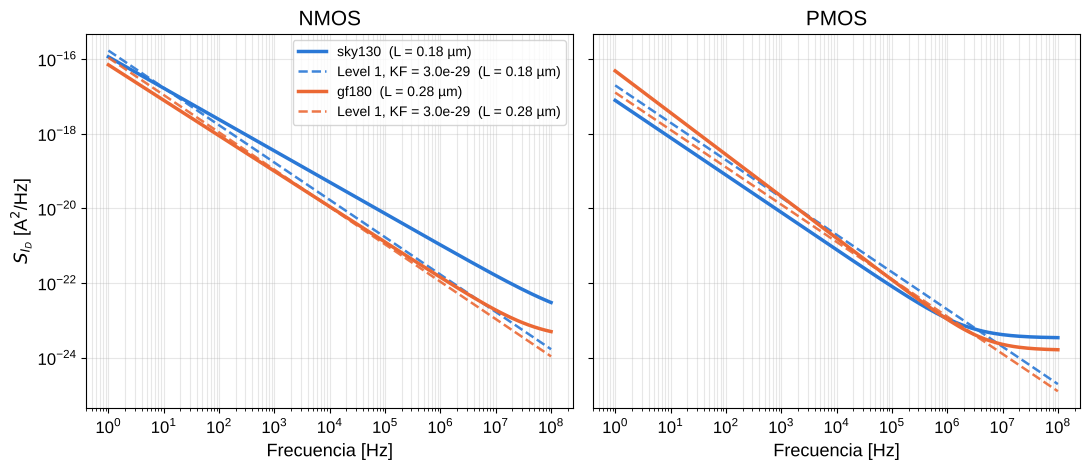

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
for ax, tipo, titulo in zip(axes, ("n", "p"), ("NMOS", "PMOS")):
    for pdk, color in (("sky130", C_SKY), ("gf180", C_GF)):
        L0 = PDKS[pdk]["L0"]
        r = [r for r in resultados if r["pdk"] == pdk and r["tipo"] == tipo and r["fnoicor"] == 0
             and r["W"] == W0 and r["L"] == L0 and abs(r["Id"] - ID_REF) < 1e-6][0]
        ax.loglog(r["f"], r["Sid"], linewidth=2.5, color=color, label=f"{pdk}  (L = {L0} µm)")
        # Level 1 con los KF propuestos, misma corriente y geometria que el PDK
        S_l1 = kf_prop[tipo] * r["Id"] / (r["f"] * (W0 * 1e-6) * (L0 * 1e-6) * Cox_razavi**2)
        ax.loglog(r["f"], S_l1, "--", linewidth=1.8, color=color, alpha=0.9,
                  label=f"Level 1, KF = {kf_prop[tipo]:.1e}  (L = {L0} µm)")
    ax.set_title(titulo, fontsize=15, weight='normal')
    ax.set_xlabel("Frecuencia [Hz]", fontsize=13)
    ax.tick_params(labelsize=12)
    ax.grid(which='both', alpha=0.3)
axes[0].set_ylabel(r"$S_{I_D}$ [A$^2$/Hz]", fontsize=13)
axes[0].legend(fontsize=10, loc="upper right")
fig.tight_layout()
plt.show()

**Dependencia con la corriente.** La pendiente de $S_{I_D}(1\,\text{Hz})$ contra $I_D$ es $A_F^{eff}$. La línea punteada gris es la pendiente 1 del Level 1 con $A_F=1$ (anclada en la corriente de referencia de cada PDK).

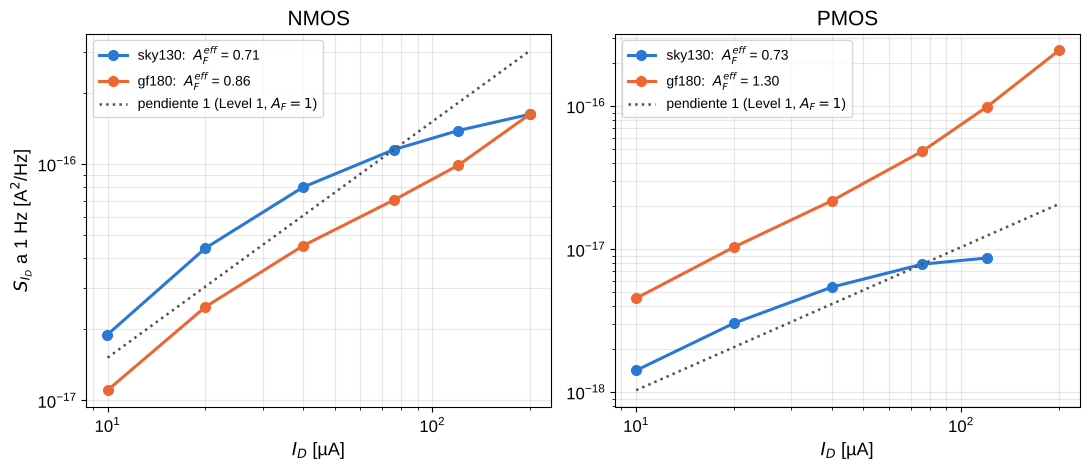

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=False)
for ax, tipo, titulo in zip(axes, ("n", "p"), ("NMOS", "PMOS")):
    for pdk, color in (("sky130", C_SKY), ("gf180", C_GF)):
        L0 = PDKS[pdk]["L0"]
        sel = [r for r in resultados if r["pdk"] == pdk and r["tipo"] == tipo and r["fnoicor"] == 0
               and r["W"] == W0 and r["L"] == L0]
        sel.sort(key=lambda r: r["Id"])
        Ids = np.array([r["Id"] for r in sel]) * 1e6
        S1 = np.array([r["Sid"][0] for r in sel])
        ax.loglog(Ids, S1, "o-", linewidth=2.2, markersize=7, color=color,
                  label=f"{pdk}:  $A_F^{{eff}}$ = {resumen[(pdk, tipo)]['af_eff']:.2f}")
    # pendiente 1 del Level 1 anclada en el punto de referencia de sky130
    r0 = [r for r in resultados if r["pdk"] == "sky130" and r["tipo"] == tipo and r["fnoicor"] == 0
          and r["W"] == W0 and r["L"] == PDKS["sky130"]["L0"] and abs(r["Id"] - ID_REF) < 1e-6][0]
    Ig = np.array(corrientes) * 1e6
    ax.loglog(Ig, r0["Sid"][0] * (Ig * 1e-6 / r0["Id"]), ":", linewidth=1.8, color=C_L1, label="pendiente 1 (Level 1, $A_F=1$)")
    ax.set_title(titulo, fontsize=15, weight='normal')
    ax.set_xlabel(r"$I_D$ [µA]", fontsize=13)
    ax.tick_params(labelsize=12)
    ax.grid(which='both', alpha=0.3)
axes[0].set_ylabel(r"$S_{I_D}$ a 1 Hz [A$^2$/Hz]", fontsize=13)
for ax in axes: ax.legend(fontsize=10, loc="upper left")
fig.tight_layout()
plt.show()

## Cómo repetirlo con otro PDK

1. Agrega una entrada a `PDKS` con la cabecera del netlist (`.lib`/`.include`), los nombres de los subcircuitos, la ruta de la corriente del dispositivo (`@m...[id]`) y las unidades de $W$ y $L$.
2. Agrega los casos y ejecuta las celdas de simulación y resultados.
3. Calcula $K_F^{eq}$ y $A_F^{eff}$ y compáralos con los de la tabla anterior.

Una versión futura puede encapsular estas simulaciones en una función que reciba el punto de operación y las dimensiones del transistor y devuelva los parámetros de pequeña señal y de ruido.